# Intraday Equity Trading Strategy

In [ ]:
import os, zipfile, math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from datetime import timedelta


# EXTRACTING DATASET + SETTING PARAMETERS

In [6]:

ZIP_PATH = "/content/archive.zip"
EXTRACT_FOLDER = "/content/nifty100_data"

LOOKBACK = 20
STOCKS_PER_SIDE = 5
RISK_FREE_RATE = 0.05

SMA_PERIOD = 50
ADX_PERIOD = 14
ADX_THRESHOLD = 18
MIN_AVG_VOLUME = 500_000
MOMENTUM_CUTOFF = 0.015
VOL_CAP = 0.18

MIN_AVG_VOL = 50_000
ATR_WINDOW = 14
VOL_LOOKBACK = 20
BASE_RISK_PER_TRADE = 0.01

OR_START = '09:15'
OR_END   = '09:45'

MAX_TRADES_PER_SYMBOL = 4
MIN_BAR_GAP = 4
ATR_STOP_MULT = 0.8
ATR_TRAIL_MULT = 2.0


#LOADING DATASET

In [7]:

if not os.path.exists(EXTRACT_FOLDER):
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall(EXTRACT_FOLDER)
    print(f"✅ Extracted dataset to {EXTRACT_FOLDER}")

def load_all_data(folder):
    data = {}
    for file in os.listdir(folder):
        if not file.endswith(".csv"): continue
        ticker = os.path.splitext(file)[0].replace("_15minute", "")
        df = pd.read_csv(os.path.join(folder, file))
        df.columns = [c.strip().capitalize() for c in df.columns]
        # unify datetime
        for alt in ['Date','Datetime','Timestamp','Time','date','DATE']:
            if alt in df.columns:
                df.rename(columns={alt:'Date'}, inplace=True)
                break
        df['Date'] = pd.to_datetime(df['Date'])
        df = df.sort_values('Date').set_index('Date')
        keep = [c for c in ['Open','High','Low','Close','Volume'] if c in df.columns]
        df = df[keep].dropna()
        data[ticker] = df
    return data

universe_data = load_all_data(EXTRACT_FOLDER)
print(f"Loaded {len(universe_data)} tickers")


✅ Extracted dataset to /content/nifty100_data
Loaded 100 tickers


#Resample Intraday Data to Daily OHLCV Format

In [8]:

def resample_daily(data_dict):
    data_daily = {}
    for t, df in data_dict.items():
        if df.empty: continue
        df_daily = df.resample('1D').agg({
            'Open':'first','High':'max','Low':'min','Close':'last','Volume':'sum'
        }).dropna()
        data_daily[t] = df_daily
    return data_daily

data_daily = resample_daily(universe_data)


#Build Daily Matrices and Compute Technical Indicators

In [9]:

tickers = sorted(data_daily.keys())
all_dates = sorted(set().union(*[df.index for df in data_daily.values()]))

def build_matrix(col):
    df_matrix = pd.DataFrame(index=all_dates, columns=tickers, dtype=float)
    for t in tickers:
        df = data_daily[t]
        df_matrix.loc[df.index, t] = df[col]
    return df_matrix.ffill() if col!='Volume' else df_matrix.fillna(0)

close_df = build_matrix('Close')
open_df  = build_matrix('Open')
high_df  = build_matrix('High')
low_df   = build_matrix('Low')
volume_df= build_matrix('Volume')

sma_df = close_df.rolling(SMA_PERIOD).mean()
avg_volume_df = volume_df.rolling(LOOKBACK).mean()
vol_df = close_df.pct_change().rolling(LOOKBACK).std()

def calculate_adx(high_s, low_s, close_s, window=ADX_PERIOD):
    plus_dm = high_s.diff().clip(lower=0)
    minus_dm = (-low_s.diff()).clip(lower=0)
    plus_dm = plus_dm.where(plus_dm>=minus_dm, 0)
    minus_dm = minus_dm.where(minus_dm>plus_dm, 0)

    tr = pd.concat([high_s - low_s,
                    (high_s - close_s.shift(1)).abs(),
                    (low_s - close_s.shift(1)).abs()], axis=1).max(axis=1)
    atr = tr.ewm(alpha=1/window, min_periods=window).mean()
    plus_di = (plus_dm.ewm(alpha=1/window, min_periods=window).mean()/atr)*100
    minus_di= (minus_dm.ewm(alpha=1/window, min_periods=window).mean()/atr)*100
    dx = ((plus_di-minus_di).abs() / (plus_di+minus_di).replace(0,np.nan))*100
    adx = dx.ewm(alpha=1/window, min_periods=window).mean()
    return adx

adx_df = pd.DataFrame(index=close_df.index, columns=close_df.columns, dtype=float)
for t in tickers:
    adx_df[t] = calculate_adx(high_df[t], low_df[t], close_df[t], ADX_PERIOD)

sma_lag = sma_df.shift(1)
adx_lag = adx_df.shift(1)
vol_lag = vol_df.shift(1)
avg_vol_lag = avg_volume_df.shift(1)
close_lag = close_df.shift(1)


#STOCK SELECTION

In [10]:

def select_stocks(date):
    date = pd.to_datetime(date)
    start = date - timedelta(days=LOOKBACK)
    hist = close_df.loc[start:date-timedelta(days=1)]
    if hist.shape[0]<2: return [],[]
    rets = (hist.iloc[-1]/hist.iloc[0]-1).dropna()
    rets = rets[rets.abs()>MOMENTUM_CUTOFF]
    if rets.empty: return [],[]
    rets_sorted = rets.sort_values(ascending=False)
    long_candidates = rets_sorted.head(STOCKS_PER_SIDE*4).index.tolist()
    short_candidates = rets_sorted.tail(STOCKS_PER_SIDE*4).index.tolist()

    def apply_filters(candidates, side):
        selected=[]
        for s in candidates:
            price = close_lag.loc[date,s]
            sma = sma_lag.loc[date,s]
            adx_val = adx_lag.loc[date,s]
            avg_vol = avg_vol_lag.loc[date,s]
            vol_val = vol_lag.loc[date,s]

            if pd.isna(price) or pd.isna(sma) or pd.isna(adx_val) or pd.isna(avg_vol) or pd.isna(vol_val):
                continue
            if avg_vol < MIN_AVG_VOLUME: continue
            if vol_val > VOL_CAP: continue
            if side=='long' and price<sma: continue
            if side=='short' and price>sma: continue
            if adx_val<ADX_THRESHOLD: continue
            selected.append(s)
            if len(selected)>=STOCKS_PER_SIDE: break
        return selected

    return apply_filters(long_candidates,'long'), apply_filters(short_candidates,'short')


#INTRADAY FEATURES

In [11]:

def intraday_atr(df):
    tr = pd.concat([df['High']-df['Low'],
                    (df['High']-df['Close'].shift(1)).abs(),
                    (df['Low']-df['Close'].shift(1)).abs()], axis=1).max(axis=1)
    return tr.rolling(ATR_WINDOW, min_periods=1).mean()

def build_profile(ticker_df):
    df = ticker_df.copy()
    df['date'] = df.index.date
    recent = sorted(df['date'].unique())[-VOL_LOOKBACK:]
    df_recent = df[df['date'].isin(recent)].copy()
    profile = df_recent.groupby(df_recent.index.time)['Close'].mean()
    profile_std = df_recent.groupby(df_recent.index.time)['Close'].std()
    return profile, profile_std

ATR_CACHE = {t: intraday_atr(universe_data[t]) for t in universe_data}
PROFILE_CACHE = {t: build_profile(universe_data[t]) for t in universe_data}

def compute_intraday_features(df, date, profile, profile_std, atr_series):
    day = pd.to_datetime(date).date()
    s = df[df.index.date==day].copy()
    if s.empty: return None
    s['time'] = s.index.time
    # VWAP
    tp = (s['High']+s['Low']+s['Close'])/3
    cum_vol = s['Volume'].cumsum().replace(0,np.nan)
    s['VWAP'] = (tp*s['Volume']).cumsum()/cum_vol
    # EMA21
    s['EMA21'] = s['Close'].ewm(span=21, adjust=False).mean()
    # ATR
    s['ATR'] = atr_series.reindex(s.index).ffill().fillna(0)
    # Opening Range
    or_slice = s.between_time(OR_START,OR_END)
    if or_slice.empty: or_slice=s.iloc[:1]
    s['ORH']=or_slice['High'].max()
    s['ORL']=or_slice['Low'].min()
    s['vol_sma10'] = s['Volume'].rolling(10,min_periods=1).mean()
    return s


#SIGNAL GENERATION

In [12]:

def generate_signals(df_feats, side):
    s=df_feats
    in_window = [(t>=pd.to_datetime('10:00').time() and t<=pd.to_datetime('14:45').time()) for t in s['time']]
    vol_pass = s['Volume']>MIN_AVG_VOL
    long_ok = (s['Close']>s['VWAP']) & (s['Close']>s['EMA21']) & (s['Close']>s['ORH'])
    short_ok= (s['Close']<s['VWAP']) & (s['Close']<s['EMA21']) & (s['Close']<s['ORL'])
    vol_surge = s['Volume']>=1.1*s['vol_sma10']
    if side=='long':
        return np.array(in_window)&vol_pass&vol_surge&long_ok
    else:
        return np.array(in_window)&vol_pass&vol_surge&short_ok


#Execute Intraday Trades and Compute Daily P&L

In [13]:

def execute_intraday(date,long_list,short_list,capital):
    trades=[]; pnl_day=0
    symbols=list(set(long_list+short_list))
    for t in symbols:
        df_feats = compute_intraday_features(universe_data[t], date, *PROFILE_CACHE[t], ATR_CACHE[t])
        if df_feats is None or len(df_feats)<2: continue
        side='long' if t in long_list else 'short'
        enters=generate_signals(df_feats, side)
        idxs=np.where(enters)[0]
        if len(idxs)==0: continue
        open_a=df_feats['Open'].values
        high_a=df_feats['High'].values
        low_a=df_feats['Low'].values
        close_a=df_feats['Close'].values
        atr_a=df_feats['ATR'].values
        taken,last_i=0,-10
        for i in idxs:
            if taken>=MAX_TRADES_PER_SYMBOL: break
            if i-last_i<MIN_BAR_GAP or i+1>=len(df_feats): continue
            entry=float(open_a[i+1])
            atr=float(atr_a[i+1])
            risk_amt=capital*BASE_RISK_PER_TRADE
            stop_pct=max(0.005, ATR_STOP_MULT*atr/entry)
            qty=max(1, math.floor(risk_amt/(entry*stop_pct)))
            nh,nl=float(high_a[i+1]),float(low_a[i+1])
            if side=='long':
                sl=entry*(1-stop_pct)
                trail=entry-ATR_TRAIL_MULT*atr
                if nl<=sl: exitp=sl
                else: exitp=max(trail,float(close_a[i+1]))
                pnl=(exitp-entry)*qty
            else:
                sl=entry*(1+stop_pct)
                trail=entry+ATR_TRAIL_MULT*atr
                if nh>=sl: exitp=sl
                else: exitp=min(trail,float(close_a[i+1]))
                pnl=(entry-exitp)*qty
            trades.append({'date':pd.to_datetime(date),'ticker':t,'side':side,
                           'entry':entry,'exit':exitp,'qty':qty,'pnl':pnl})
            pnl_day+=pnl; taken+=1; last_i=i
    return pnl_day,trades


#BACKTESTING LOOP

In [14]:

def backtest_intraday(selection_dates, capital):
    results=[]; all_trades=[]
    for d in tqdm(selection_dates, desc="Intraday Backtest"):
        long_list, short_list = select_stocks(d)
        pnl_day,trades=execute_intraday(d,long_list,short_list,capital)
        results.append({'date':pd.to_datetime(d),'pnl':pnl_day,'ntrades':len(trades)})
        all_trades+=trades
    df_res=pd.DataFrame(results).set_index('date') if results else pd.DataFrame(columns=['pnl','ntrades'])
    trades_df=pd.DataFrame(all_trades)
    return df_res,trades_df



#RUN BACKTEST

In [15]:

start_date=pd.to_datetime("2024-08-07")
end_date=pd.to_datetime("2025-08-06")
selection_dates=[d for d in close_df.index if start_date<=d<=end_date]
initial_capital=100_000.0

df_res,trades_df=backtest_intraday(selection_dates,initial_capital)


Intraday Backtest: 100%|██████████| 250/250 [01:33<00:00,  2.68it/s]


#CALCULATE METRICS

In [16]:

if not df_res.empty:
    df_res['daily_ret']=df_res['pnl']/initial_capital
    df_res['equity']=(1+df_res['daily_ret']).cumprod()*initial_capital
    df_res['cum_ret_pct']=(df_res['equity']/initial_capital-1)*100

    daily_ret=df_res['daily_ret'].values
    N=len(daily_ret)
    prod_ret=np.prod(1+daily_ret) if N>0 else 1
    annual_ret=(prod_ret**(252.0/N)-1)*100 if N>0 else np.nan
    sharpe=(np.mean(daily_ret)/np.std(daily_ret))*np.sqrt(252) if np.std(daily_ret)>0 else np.nan
    neg_std = df_res[df_res['daily_ret'] < 0]['daily_ret'].std()
    sortino = (df_res['daily_ret'].mean() / neg_std) * np.sqrt(252) if neg_std and neg_std > 0 else np.nan

    drawdown=(df_res['equity']/df_res['equity'].cummax()-1)*100
    max_dd=float(drawdown.min())

    print("\n===== Strategy Performance =====")
    print(f"Initial Capital     : ₹{initial_capital:,.2f}")
    print(f"Final Capital       : ₹{df_res['equity'].iloc[-1]:,.2f}")
    print(f"Cumulative Return   : {df_res['cum_ret_pct'].iloc[-1]:.2f}%")
    print(f"Annualized Return   : {annual_ret:.2f}%")
    print(f"Sharpe Ratio        : {sharpe:.2f}")
    print(f"Sortino Ratio       : {sortino:.2f}")
    print(f"Max Drawdown        : {max_dd:.2f}%")
    print(f"Total Trades        : {len(trades_df)}")
    print(f"Avg PnL per Trade   : {trades_df['pnl'].mean():.2f}")
    print(f"Win Rate            : {100*sum(trades_df['pnl']>0)/len(trades_df):.2f}%")




===== Strategy Performance =====
Initial Capital     : ₹100,000.00
Final Capital       : ₹127,971.68
Cumulative Return   : 27.97%
Annualized Return   : 28.22%
Sharpe Ratio        : 1.20
Sortino Ratio       : 2.17
Max Drawdown        : -19.00%
Total Trades        : 1248
Avg PnL per Trade   : 21.82
Win Rate            : 49.28%


#PLOTS

/tmp/ipykernel_8362/3067193396.py:13: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8362/3067193396.py:14: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig("daily_returns.png")  # <-- saves plot as PNG
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


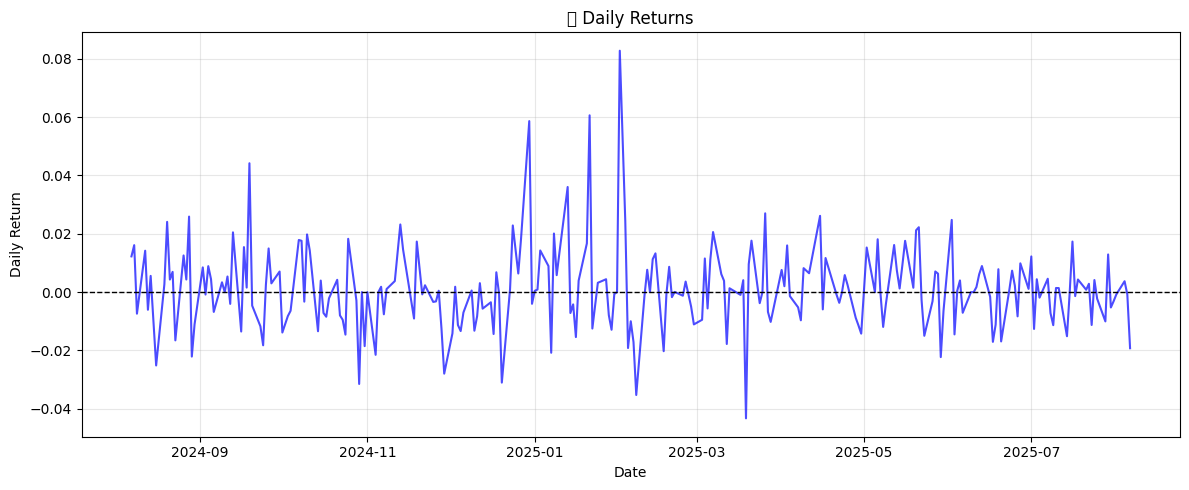

/tmp/ipykernel_8362/3067193396.py:24: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8362/3067193396.py:25: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  plt.savefig("equity_curve.png")  # <-- saves plot as PNG
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


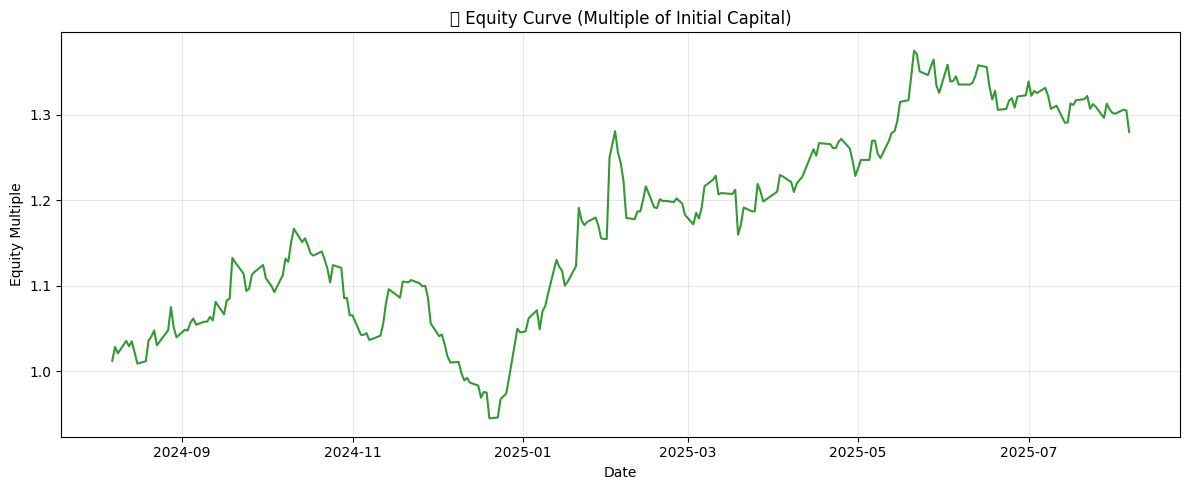

/tmp/ipykernel_8362/3067193396.py:36: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8362/3067193396.py:37: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig("drawdown.png")  # <-- saves plot as PNG
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


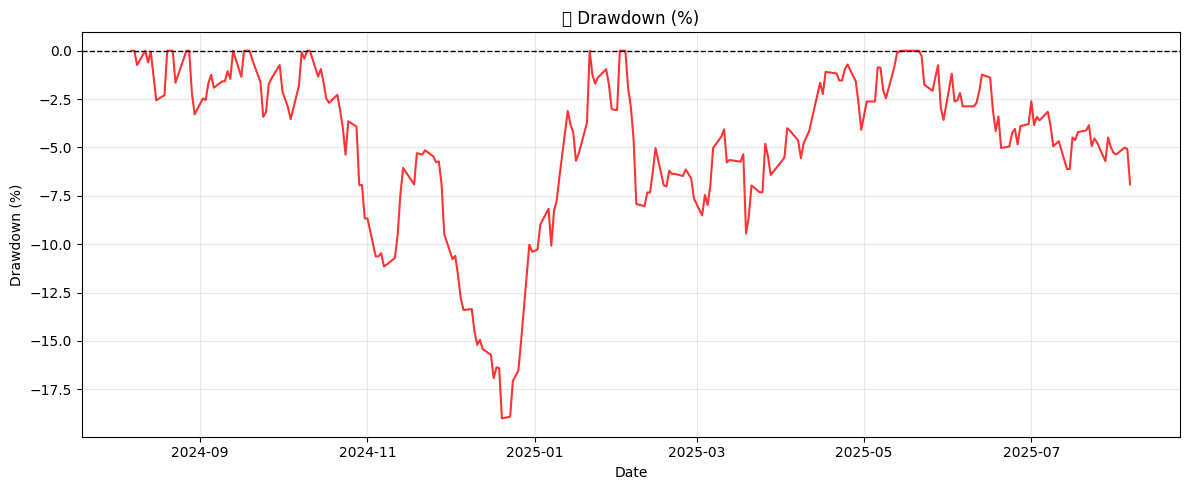

In [17]:
# ---- STEP 11: PLOTS & SAVE ----
if not df_res.empty:
    import matplotlib.dates as mdates

    # 1️⃣ Daily Returns Plot
    plt.figure(figsize=(12,5))
    plt.plot(df_res.index, df_res['daily_ret'], color='blue', alpha=0.7)
    plt.axhline(0, color='black', linestyle='--', linewidth=1)
    plt.title("📊 Daily Returns")
    plt.ylabel("Daily Return")
    plt.xlabel("Date")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("daily_returns.png")  # <-- saves plot as PNG
    plt.show()

    # 2️⃣ Equity Curve Plot
    plt.figure(figsize=(12,5))
    plt.plot(df_res.index, df_res['equity']/initial_capital, color='green', alpha=0.8)
    plt.title("💰 Equity Curve (Multiple of Initial Capital)")
    plt.ylabel("Equity Multiple")
    plt.xlabel("Date")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("equity_curve.png")  # <-- saves plot as PNG
    plt.show()

    # 3️⃣ Drawdown Plot
    plt.figure(figsize=(12,5))
    plt.plot(df_res.index, drawdown, color='red', alpha=0.8)
    plt.title("📉 Drawdown (%)")
    plt.ylabel("Drawdown (%)")
    plt.xlabel("Date")
    plt.axhline(0, color='black', linestyle='--', linewidth=1)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("drawdown.png")  # <-- saves plot as PNG
    plt.show()
